In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
transaction = pd.read_excel("QVI_transaction_data.xlsx")
customer = pd.read_csv("QVI_purchase_behaviour.csv")

In [43]:
transaction.shape
customer.shape

(72637, 3)

In [44]:
transaction.head()
customer.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [45]:
transaction.columns
customer.columns

Index(['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER'], dtype='str')

In [46]:
transaction.info()
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  str    
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), str(1)
memory usage: 16.2 MB
<class 'pandas.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LYLTY_CARD_NBR    72637 non-null  int64
 1   LIFESTAGE         72637 non-null  str  
 2   PREMIUM_CUSTOMER  72637 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


In [47]:
transaction.isnull().sum()
customer.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [48]:
transaction.dropna(inplace=True)

In [49]:
transaction.duplicated().sum()
customer.duplicated().sum()

np.int64(0)

In [50]:
transaction.drop_duplicates(inplace=True)
customer.drop_duplicates(inplace=True)

In [51]:
transaction.info()

<class 'pandas.DataFrame'>
Index: 264835 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264835 non-null  int64  
 1   STORE_NBR       264835 non-null  int64  
 2   LYLTY_CARD_NBR  264835 non-null  int64  
 3   TXN_ID          264835 non-null  int64  
 4   PROD_NBR        264835 non-null  int64  
 5   PROD_NAME       264835 non-null  str    
 6   PROD_QTY        264835 non-null  int64  
 7   TOT_SALES       264835 non-null  float64
dtypes: float64(1), int64(6), str(1)
memory usage: 18.2 MB


In [52]:
transaction['DATE'] = pd.to_datetime(
    transaction['DATE'],
    origin='1899-12-30',
    unit='D'
)

In [53]:
transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [54]:
transaction['PROD_NAME'].head(20)

0       Natural Chip        Compny SeaSalt175g
1                     CCs Nacho Cheese    175g
2       Smiths Crinkle Cut  Chips Chicken 170g
3       Smiths Chip Thinly  S/Cream&Onion 175g
4     Kettle Tortilla ChpsHny&Jlpno Chili 150g
5     Old El Paso Salsa   Dip Tomato Mild 300g
6     Smiths Crinkle Chips Salt & Vinegar 330g
7        Grain Waves         Sweet Chilli 210g
8      Doritos Corn Chip Mexican Jalapeno 150g
9        Grain Waves Sour    Cream&Chives 210G
10    Smiths Crinkle Chips Salt & Vinegar 330g
11       Kettle Sensations   Siracha Lime 150g
12                    Twisties Cheese     270g
13            WW Crinkle Cut      Chicken 175g
14              Thins Chips Light&  Tangy 175g
15                           CCs Original 175g
16                           Burger Rings 220g
17      NCC Sour Cream &    Garden Chives 175g
18     Doritos Corn Chip Southern Chicken 150g
19                    Cheezels Cheese Box 125g
Name: PROD_NAME, dtype: str

In [55]:
transaction['PROD_NAME'].value_counts()


PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
                                            ... 
RRD Pc Sea Salt     165g                    1431
Woolworths Medium   Salsa 300g              1430
NCC Sour Cream &    Garden Chives 175g      1419
French Fries Potato Chips 175g              1418
WW Crinkle Cut      Original 175g           1410
Name: count, Length: 114, dtype: int64

In [56]:
transaction = transaction[
    ~transaction['PROD_NAME']
    .str.contains('salsa', case=False)
]

In [57]:
transaction['PROD_QTY'].describe()

count    246741.000000
mean          1.908061
std           0.659832
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

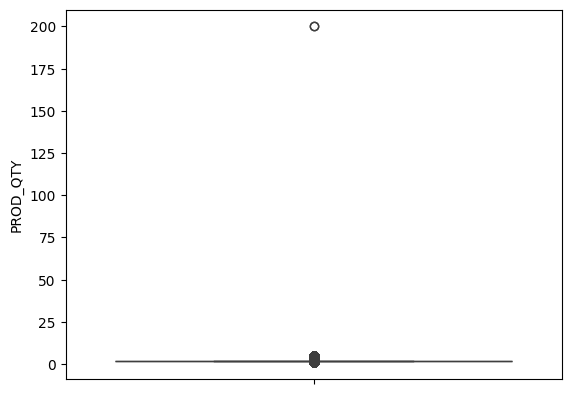

In [58]:
sns.boxplot(transaction['PROD_QTY'])
plt.show()

In [59]:
transaction[
    transaction['PROD_QTY'] > 50
]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [60]:
transaction = transaction[
    transaction['PROD_QTY'] < 50
]

In [61]:
transaction['PACK_SIZE'] = (
    transaction['PROD_NAME']
    .str.extract('(\d+)')
    .astype(int)
)


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Krish\AppData\Local\Temp\ipykernel_18128\240515550.py:3: SyntaxWarning: invalid escape sequence '\d'
  .str.extract('(\d+)')


In [62]:
transaction['BRAND'] = (
    transaction['PROD_NAME']
    .str.split()
    .str[0]
)

In [63]:
transaction['BRAND'] = (
    transaction['BRAND']
    .replace({
        'Red':'RRD',
        'Smith':'Smiths',
        'Dorito':'Doritos'
    })
)


In [64]:
merged = transaction.merge(
    customer,
    on='LYLTY_CARD_NBR',
    how='left'
)

In [65]:
merged.head()


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [66]:
merged['TOT_SALES'].sum()

np.float64(1805171.7)

In [67]:
merged['PROD_QTY'].sum()

np.int64(470397)

In [68]:
merged.groupby(
    'LIFESTAGE'
)['TOT_SALES'].mean()


LIFESTAGE
MIDAGE SINGLES/COUPLES    7.373442
NEW FAMILIES              7.287664
OLDER FAMILIES            7.274899
OLDER SINGLES/COUPLES     7.403009
RETIREES                  7.373994
YOUNG FAMILIES            7.275841
YOUNG SINGLES/COUPLES     7.175854
Name: TOT_SALES, dtype: float64

In [69]:
segment_sales = merged.groupby(
    ['LIFESTAGE','PREMIUM_CUSTOMER']
)['TOT_SALES'].sum()

In [70]:
merged.groupby(
    'LIFESTAGE'
)['PROD_QTY'].mean()

LIFESTAGE
MIDAGE SINGLES/COUPLES    1.901701
NEW FAMILIES              1.857781
OLDER FAMILIES            1.946410
OLDER SINGLES/COUPLES     1.913352
RETIREES                  1.892593
YOUNG FAMILIES            1.940460
YOUNG SINGLES/COUPLES     1.834025
Name: PROD_QTY, dtype: float64

In [71]:
merged['PRICE_PER_UNIT'] = (
    merged['TOT_SALES']
    / merged['PROD_QTY']
)

In [72]:
merged.groupby(
    'PREMIUM_CUSTOMER'
)['PRICE_PER_UNIT'].mean()

PREMIUM_CUSTOMER
Budget        3.801726
Mainstream    3.873657
Premium       3.813071
Name: PRICE_PER_UNIT, dtype: float64

In [73]:
merged.groupby(
['LIFESTAGE','PREMIUM_CUSTOMER']
)['TOT_SALES'].sum().sort_values(
ascending=False
)

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              156863.75
YOUNG SINGLES/COUPLES   Mainstream          147582.20
RETIREES                Mainstream          145168.95
YOUNG FAMILIES          Budget              129717.95
OLDER SINGLES/COUPLES   Budget              127833.60
                        Mainstream          124648.50
                        Premium             123531.55
RETIREES                Budget              105916.30
OLDER FAMILIES          Mainstream           96413.55
RETIREES                Premium              91296.65
YOUNG FAMILIES          Mainstream           86338.25
MIDAGE SINGLES/COUPLES  Mainstream           84734.25
YOUNG FAMILIES          Premium              78571.70
OLDER FAMILIES          Premium              75242.60
YOUNG SINGLES/COUPLES   Budget               57122.10
MIDAGE SINGLES/COUPLES  Premium              54443.85
YOUNG SINGLES/COUPLES   Premium              39052.30
MIDAGE SINGLES/COUPLES  Budget           

In [74]:
merged.groupby(
['LIFESTAGE','BRAND']
)['TOT_SALES'].sum()

LIFESTAGE               BRAND     
MIDAGE SINGLES/COUPLES  Burger          660.1
                        CCs            1717.8
                        Cheetos        1499.7
                        Cheezels       4080.6
                        Cobs           6995.8
                                       ...   
YOUNG SINGLES/COUPLES   Tostitos      11149.6
                        Twisties      11653.7
                        Tyrrells       7413.0
                        WW             4095.8
                        Woolworths      604.8
Name: TOT_SALES, Length: 175, dtype: float64

In [75]:
merged.groupby(
['LIFESTAGE']
)['PACK_SIZE'].mean()

LIFESTAGE
MIDAGE SINGLES/COUPLES    176.075776
NEW FAMILIES              175.166538
OLDER FAMILIES            175.202312
OLDER SINGLES/COUPLES     175.534395
RETIREES                  175.880102
YOUNG FAMILIES            174.875438
YOUNG SINGLES/COUPLES     176.343166
Name: PACK_SIZE, dtype: float64

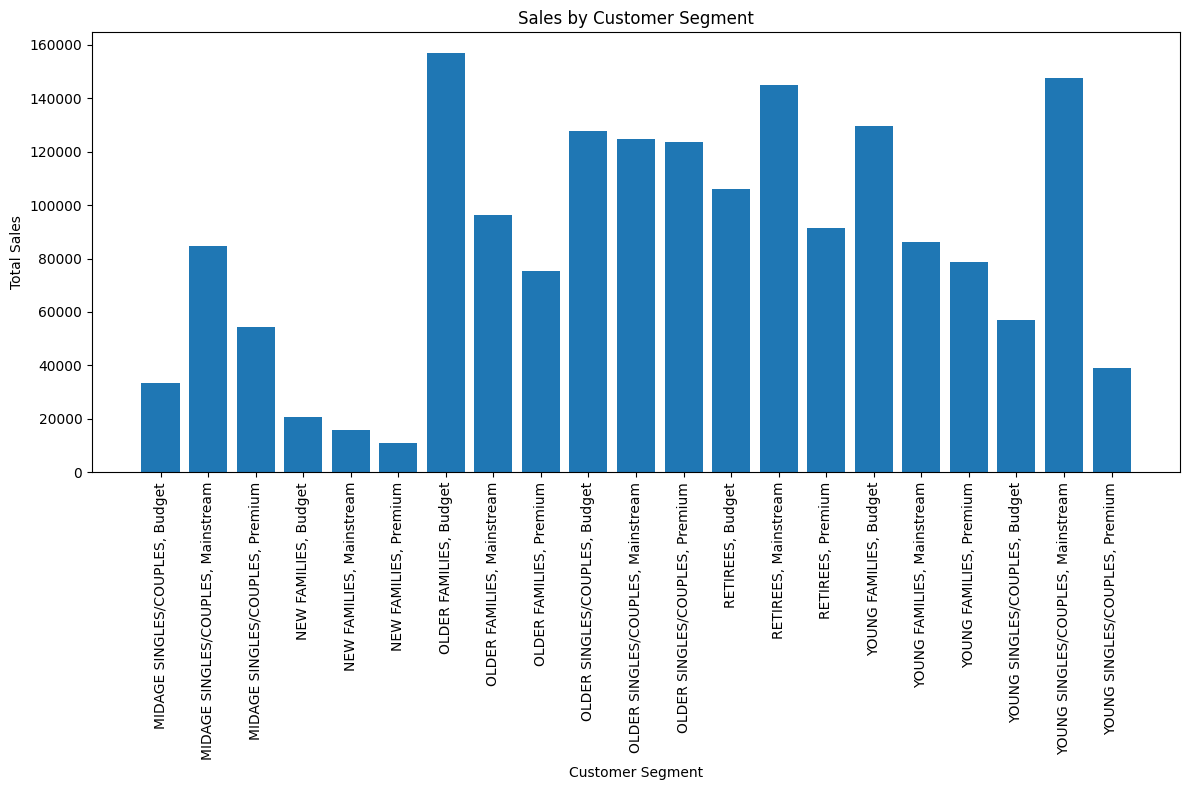

In [77]:
sales_segment = merged.groupby(
    ['LIFESTAGE', 'PREMIUM_CUSTOMER']
)['TOT_SALES'].sum().reset_index()

sales_segment['Segment'] = (
    sales_segment['LIFESTAGE']
    + ', ' +
    sales_segment['PREMIUM_CUSTOMER']
)

plt.figure(figsize=(12,8))

plt.bar(
    sales_segment['Segment'],
    sales_segment['TOT_SALES']
)

plt.title(
    'Sales by Customer Segment'
)

plt.xlabel(
    'Customer Segment'
)

plt.ylabel(
    'Total Sales'
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

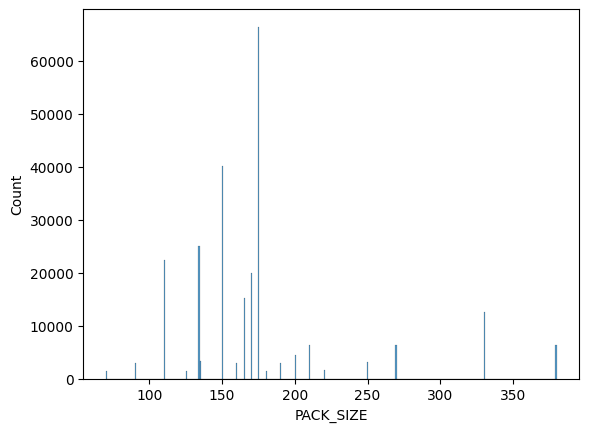

In [ ]:
sns.histplot(
merged['PACK_SIZE']
)
plt.show()

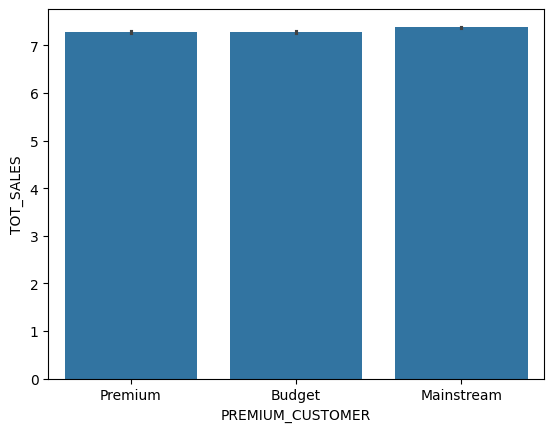

In [ ]:
sns.barplot(
x='PREMIUM_CUSTOMER',
y='TOT_SALES',
data=merged
)
plt.show()

In [ ]:
merged.to_csv(
'cleaned_quantium_data.csv',
index=False
)


In [78]:
plt.savefig(
'sales_segment.png'
)

<Figure size 640x480 with 0 Axes>

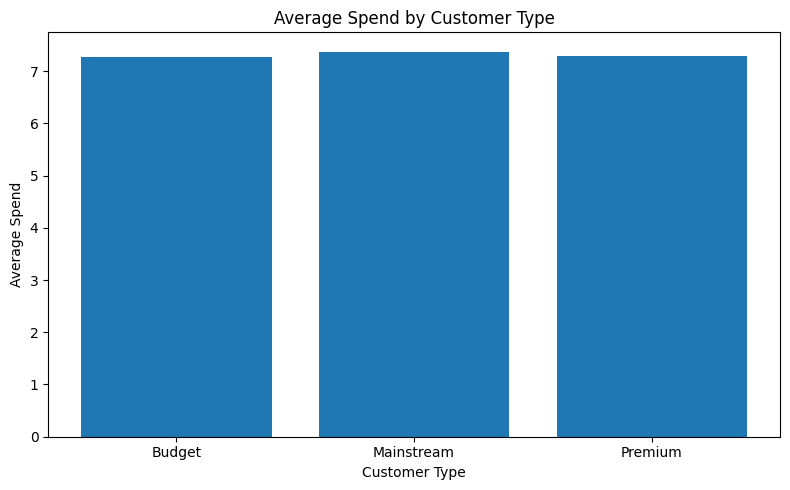

In [79]:
affluence = merged.groupby(
    'PREMIUM_CUSTOMER'
)['TOT_SALES'].mean().reset_index()

plt.figure(figsize=(8,5))

plt.bar(
    affluence['PREMIUM_CUSTOMER'],
    affluence['TOT_SALES']
)

plt.title(
    'Average Spend by Customer Type'
)

plt.xlabel(
    'Customer Type'
)

plt.ylabel(
    'Average Spend'
)

plt.tight_layout()

plt.show()

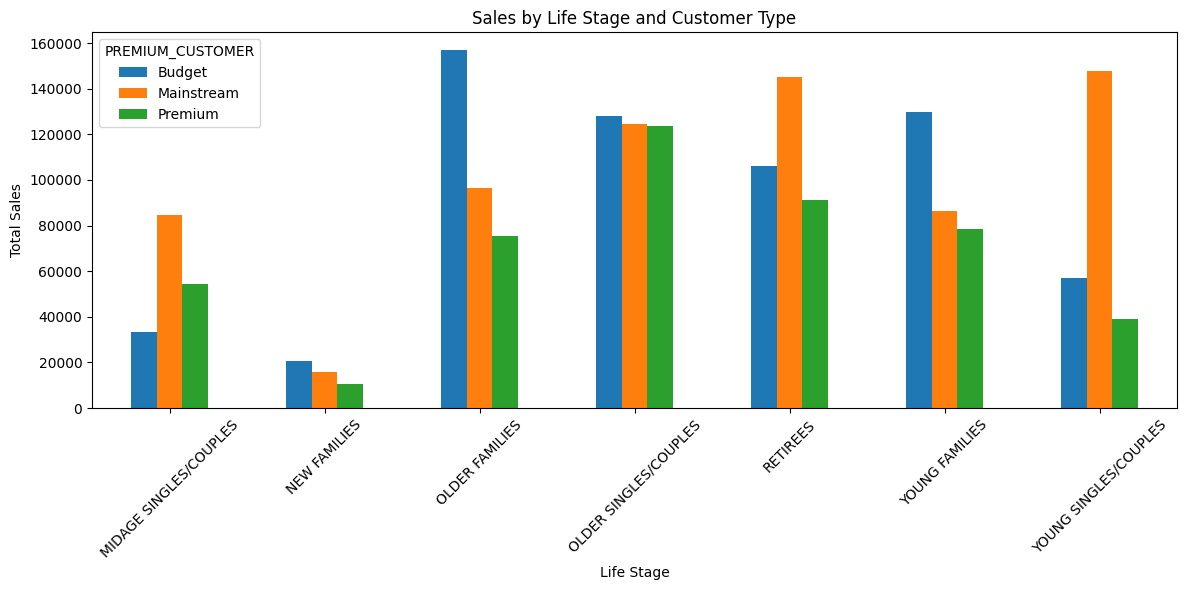

In [80]:
stretch = merged.pivot_table(
    values='TOT_SALES',
    index='LIFESTAGE',
    columns='PREMIUM_CUSTOMER',
    aggfunc='sum'
)

stretch.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    'Sales by Life Stage and Customer Type'
)

plt.xlabel(
    'Life Stage'
)

plt.ylabel(
    'Total Sales'
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()